# Corporate Credit Rating — Clustering Track
This notebook performs unsupervised clustering on the preprocessed financial dataset using K-Means and Agglomerative Hierarchical Clustering.

## 1. Import Libraries

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy.cluster.hierarchy import dendrogram, linkage

import os

## Load Preprocessed Clustering Data

In [37]:
data_dir = '../data'

X_cluster = pd.read_csv(
    os.path.join(data_dir, 'clustering_preprocessed.csv')
)

print("Dataset shape:", X_cluster.shape)
X_cluster.head()

Dataset shape: (7805, 28)


,Current Ratio,Long-term Debt / Capital,Debt/Equity Ratio,Gross Margin,Operating Margin,EBIT Margin,EBITDA Margin,Pre-Tax Profit Margin,Net Profit Margin,Asset Turnover,...,Sector_Durbl,Sector_Enrgy,Sector_Hlth,Sector_Manuf,Sector_Money,Sector_NoDur,Sector_Other,Sector_Shops,Sector_Telcm,Sector_Utils
0,-0.652359,0.100246,-0.001379,1.499593,0.567575,0.560979,0.524631,0.277196,0.075058,-0.950148,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-0.695584,-2.043248,-1.215912,0.053653,0.599186,0.592507,0.190413,0.938497,0.689602,-0.919916,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.236038,-0.678379,-0.637023,-1.298618,-0.897565,-0.900336,-1.154551,-0.684225,-0.648886,2.367658,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-1.012451,0.175381,0.087766,0.941272,0.474319,0.467966,0.455363,0.414200,0.157308,-0.995596,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-0.489522,-0.812378,-0.667338,-1.641882,-1.077950,-1.080250,-1.290286,-0.850283,-0.087392,2.367658,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [38]:
print("Shape:", X_cluster.shape)
print("\nMissing values:", X_cluster.isnull().sum().sum())
print("\nData types:")
print(X_cluster.dtypes.value_counts())

Shape: (7805, 28)

Missing values: 0

Data types:
float64    28
Name: count, dtype: int64


## Clustering Models

In [39]:
clu_models = {}
clu_results = []

def add_clu_result(name, model, labels):
    clu_models[name] = model

    sil = silhouette_score(X_cluster, labels)
    db = davies_bouldin_score(X_cluster, labels)
    ch = calinski_harabasz_score(X_cluster, labels)

    clu_results.append([
        name, sil, db, ch
    ])

    print(name)
    print("Silhouette Score:", sil)
    print("Davies-Bouldin Index:", db)
    print("Calinski-Harabasz Index:", ch)
    print()

## K-Means Clustering

K-Means partitions the observations into a predefined number of clusters. The Elbow Method is used to determine a suitable number of clusters by examining the within-cluster sum of squares (inertia).

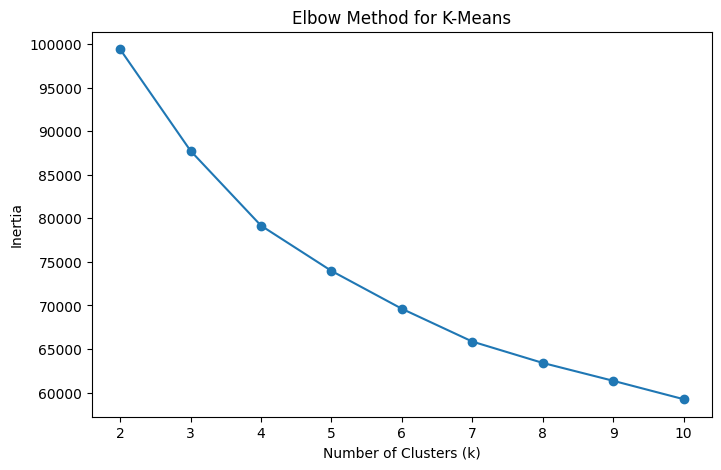

In [40]:
# Calculate inertia for different values of k

inertia = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_cluster)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))

plt.plot(range(2, 11), inertia, marker='o')

plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for K-Means')

plt.show()

In [41]:
# Choose k based on the elbow plot
k = 3

kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_cluster)

# Store results
add_clu_result(
    "K-Means",
    kmeans,
    kmeans_labels
)

# Display results
clu_results_df = pd.DataFrame(
    clu_results,
    columns=[
        "Model",
        "Silhouette Score",
        "Davies-Bouldin Index",
        "Calinski-Harabasz Index"
    ]
)

K-Means
Silhouette Score: 0.1775518180505559
Davies-Bouldin Index: 1.7440436347851602
Calinski-Harabasz Index: 1998.384819864352



### PCA Visualization for K-Means

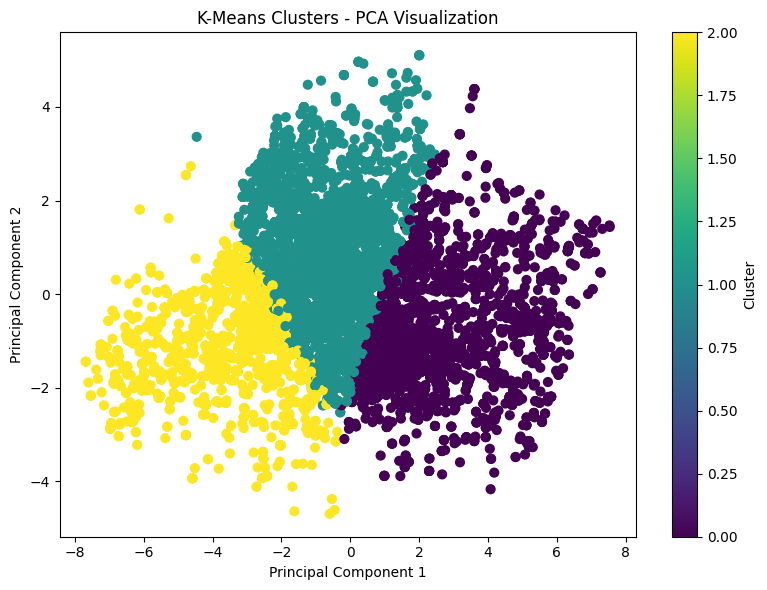

Explained variance ratio: [0.4072182  0.15180591]
Total explained variance: 0.5590241074059225


In [42]:
pca = PCA(n_components=2, random_state=42)

X_pca = pca.fit_transform(X_cluster)

plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=kmeans_labels,
    cmap='viridis',
    s=40
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters - PCA Visualization")

plt.colorbar(label="Cluster")
plt.tight_layout()
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

## Agglomerative Hierarchical Clustering - Dendrogram

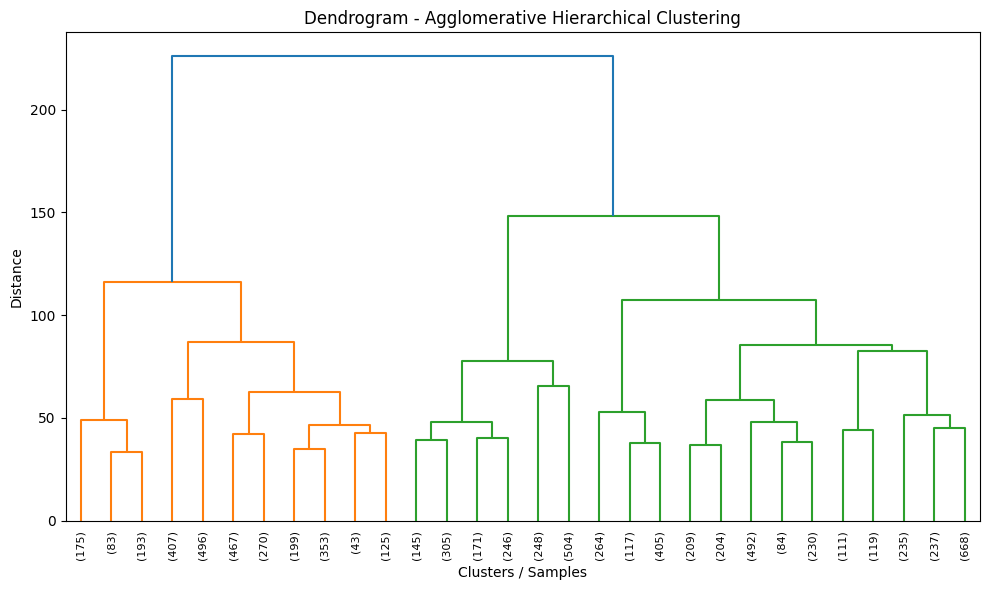

In [43]:
plt.figure(figsize=(10, 6))

linkage_matrix = linkage(
    X_cluster,
    method='ward'
)

dendrogram(
    linkage_matrix,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90,
    leaf_font_size=8
)

plt.xlabel("Clusters / Samples")
plt.ylabel("Distance")
plt.title("Dendrogram - Agglomerative Hierarchical Clustering")
plt.tight_layout()
plt.show()

In [44]:
# Agglomerative Hierarchical Clustering

hierarchical = AgglomerativeClustering(
    n_clusters=2,
    linkage='ward'
)

hier_labels = hierarchical.fit_predict(X_cluster)

# Store and evaluate results
add_clu_result(
    "Agglomerative Hierarchical",
    hierarchical,
    hier_labels
)

# Display clustering results
clu_results_df = pd.DataFrame(
    clu_results,
    columns=[
        "Model",
        "Silhouette Score",
        "Davies-Bouldin Index",
        "Calinski-Harabasz Index"
    ]
)

Agglomerative Hierarchical
Silhouette Score: 0.16844247144721652
Davies-Bouldin Index: 1.845803454444261
Calinski-Harabasz Index: 1866.8009203269821



### PCA Visualization for Hierarchical Clustering

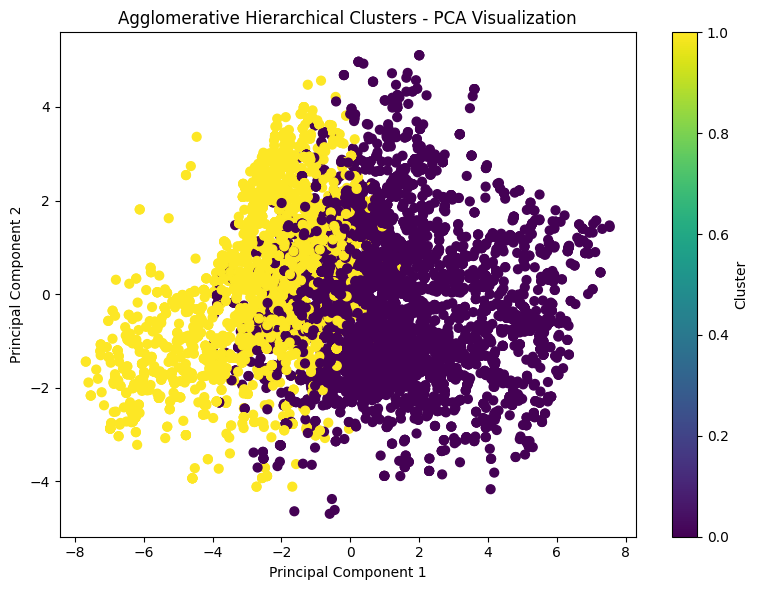

Explained variance ratio: [0.4072182  0.15180591]
Total explained variance: 0.5590241074059225


In [45]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_cluster)

plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=hier_labels,
    cmap='viridis',
    s=40
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Agglomerative Hierarchical Clusters - PCA Visualization")

plt.colorbar(label="Cluster")
plt.tight_layout()
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

## t-SNE Visualization for K-Means

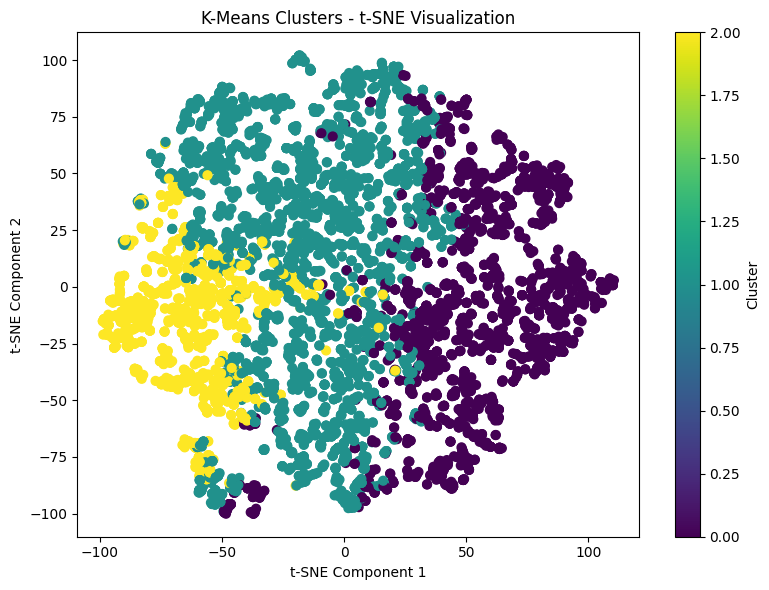

In [46]:
tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30
)

X_tsne = tsne.fit_transform(X_cluster)

plt.figure(figsize=(8, 6))

plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=kmeans_labels,
    cmap='viridis',
    s=40
)

plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.title("K-Means Clusters - t-SNE Visualization")

plt.colorbar(label="Cluster")
plt.tight_layout()
plt.show()

## Comparision of the two algorithms

In [47]:
clu_results_df = pd.DataFrame(
    clu_results,
    columns=[
        "Model",
        "Silhouette Score",
        "Davies-Bouldin Index",
        "Calinski-Harabasz Index"
    ]
)

print("Clustering Model Comparison")
display(clu_results_df)

# Cluster sizes
print("\nK-Means Cluster Distribution:")
print(pd.Series(kmeans_labels).value_counts().sort_index())

print("\nHierarchical Cluster Distribution:")
print(pd.Series(hier_labels).value_counts().sort_index())

Clustering Model Comparison


,Model,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index
0,K-Means,0.177552,1.744044,1998.38482
1,Agglomerative Hierarchical,0.168442,1.845803,1866.80092



K-Means Cluster Distribution:
0    2646
1    3901
2    1258
Name: count, dtype: int64

Hierarchical Cluster Distribution:
0    4994
1    2811
Name: count, dtype: int64


## Clustering Results and Observations

- K-Means achieved a Silhouette Score of 0.177552, compared with 0.168442 for Agglomerative Hierarchical Clustering.
- K-Means recorded a lower Davies-Bouldin Index of 1.744044, compared with 1.845803 for Agglomerative Hierarchical Clustering.
- K-Means obtained a higher Calinski-Harabasz Index of 1998.38, compared with 1866.80 for Agglomerative Hierarchical Clustering.
- Based on all three evaluation metrics, the K-Means clustering produced better-separated and more compact clusters for this dataset.
- K-Means divided the observations into three clusters with sizes 2646, 3901, and 1258.
- Agglomerative Hierarchical Clustering divided the observations into two clusters with sizes 4994 and 2811.
- The PCA and t-SNE visualizations provide a two-dimensional representation of the cluster assignments.